In [13]:
# import python and pytorch libraries
from __future__ import absolute_import
from __future__ import print_function

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import codecs
import os
import sys
import numpy as np
import logging
import tempfile
import shutil
import pickle
import platform
import json
from datetime import datetime
import random
from sklearn import metrics
import matplotlib.pyplot as plt
import itertools
import collections
from collections import defaultdict

In [15]:
import import_ipynb
from mimic_utils_text import InHospitalMortalityReader, Discretizer, Normalizer, read_chunk

# Pytorch Dataset

In [27]:
# pad missing values in the nested lists with 0s
def pad_missing_value_with_zero(data):
    a1 = np.zeros((len(data), max([len(k) for k in data]), 35))  # 35
    for ctr, k in enumerate(data):
        # print(ctr, len(k), k)
        # Convert string representations of Boolean values to numerical values
        k = np.array([[1.0 if val == 'True' else 0.0 if val == 'False' else float(val) for val in row] for row in k])
        
        a1[ctr, : len(k), :] = k
    return a1

In [17]:
# pytroch class for reading data into batches
class MIMICDataset(Dataset):
    """
    Loads time series data into memory from a text file,
    split by newlines.
    """

    def __init__(self, reader, target_repl=False, batch_labels=False):
        self.data = []
        self.y = []
        N = reader.get_number_of_examples()
        print(f'Number of examples:{N}')
        # read data form cvs files
        ret = read_chunk(reader, N)
        # read into memory structured data X and labels y
        # print(ret)
        
        data = ret["X"]
        ts = ret["t"]
        labels = ret["y"]
        names = ret["name"]

        # print(data)

        # pad missing values in the list of arrays with 0s
        data = pad_missing_value_with_zero(data)

        self.data = np.array(data, dtype=np.float32)
        self.T = self.data.shape[1]

        if batch_labels:
            self.y = np.array([[l] for l in labels], dtype=np.float32)
        else:
            self.y = np.array(labels, dtype=np.float32)
        if target_repl:
            self.y = self._extend_labels(self.y)

    def _extend_labels(self, labels):
        # (B,)
        labels = labels.repeat(self.T, axis=1)  # (B, T)
        return labels

    def __len__(self):
        # overide len to get number of instances
        return len(self.data)

    def __getitem__(self, idx):
        # get features (physiological variables x) and label for a given instance index
        return self.data[idx], self.y[idx]

# Evaluation metrics
The main measure used are accuracy, ROC AUC and PR AUC.

In [18]:
# eval metrics
def print_metrics_binary(y_true, predictions, logging, verbose=1):
    predictions = np.array(predictions)
    if len(predictions.shape) == 1:
        predictions = np.stack([1 - predictions, predictions]).transpose((1, 0))
    cf = metrics.confusion_matrix(y_true, predictions.argmax(axis=1))
    if verbose:
        logging.info("confusion matrix:")
        logging.info(cf)
    cf = cf.astype(np.float32)

    acc = (cf[0][0] + cf[1][1]) / np.sum(cf)
    prec0 = cf[0][0] / (cf[0][0] + cf[1][0])
    prec1 = cf[1][1] / (cf[1][1] + cf[0][1])
    rec0 = cf[0][0] / (cf[0][0] + cf[0][1])
    rec1 = cf[1][1] / (cf[1][1] + cf[1][0])
    auroc = metrics.roc_auc_score(y_true, predictions[:, 1])

    (precisions, recalls, thresholds) = metrics.precision_recall_curve(y_true, predictions[:, 1])
    auprc = metrics.auc(recalls, precisions)
    minpse = np.max([min(x, y) for (x, y) in zip(precisions, recalls)])

    if verbose:
        logging.info("accuracy = {0:.3f}".format(acc))
        logging.info("precision class 0 = {0:.3f}".format(prec0))
        logging.info("precision class 1 = {0:.3f}".format(prec1))
        logging.info("recall class 0 = {0:.3f}".format(rec0))
        logging.info("recall class 1 = {0:.3f}".format(rec1))
        logging.info("AUC of ROC = {0:.3f}".format(auroc))
        logging.info("AUC of PRC = {0:.3f}".format(auprc))

    return {"acc": acc, "prec0": prec0, "prec1": prec1, "rec0": rec0, "rec1": rec1, "auroc": auroc, "auprc": auprc}

In [19]:
def performance_with_cutoff(y_test, pred_probabilities, verbose=1):
    # performance
    fpr, tpr, thresholds = metrics.roc_curve(y_test, pred_probabilities)
    # compute roc auc
    roc_auc = metrics.roc_auc_score(y_test, pred_probabilities, average="micro")
    # compute Precision_Recall curves
    precision, recall, _ = metrics.precision_recall_curve(y_test, pred_probabilities)
    # compute PR_AUC
    pr_auc = metrics.auc(recall, precision)

    # compute confusion matrix
    optimal_cut_off = round(thresholds[np.argmax(tpr - fpr)], 4)
    a = np.where(pred_probabilities > optimal_cut_off, 1, 0)
    brier = round(metrics.brier_score_loss(y_test, pred_probabilities, sample_weight=None, pos_label=None), 3)
    predictions = np.where(pred_probabilities > optimal_cut_off, 1, 0)
    matrix = metrics.confusion_matrix(y_test, a, labels=None, normalize=None)

    if verbose:
        print("confusion matrix after tuning with cutoff")
        print("Cut off: " + str(optimal_cut_off))
        print(matrix)
        print("accuracy with cutoff = {0:.3f}".format(metrics.accuracy_score(y_test, predictions)))

# Training
Here we define the model, loss and training loop. The model is an LSTM. 

In [20]:
# model
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        tag_size,
        hidden_size,
        feat_size,
        emb_size,
        bidirectional=False,
        dropout=0.2,
        aggregation_type="last_state",
    ):
        """
        constructor, here we define the hidden layers for our architecture
        """
        super().__init__()
        # define if the rnn will be bidirectional
        self.bidirectional = bidirectional
        # define the aggregation type of the features for the classifier for example, you can take the mean
        self.aggregation_type = aggregation_type
        self.encoder = nn.Linear(feat_size, emb_size, bias=True)
        # Create a (bidirectional) LSTM to encode sequence
        self.lstm = nn.LSTM(emb_size, hidden_size, batch_first=True, bidirectional=bidirectional)

        # The output of the LSTM doubles if we use a bidirectional encoder.
        encoding_size = hidden_size * 2 if bidirectional else hidden_size
        self.combination_layer = nn.Linear(encoding_size, encoding_size)

        # Create affine layer to project to the classes
        self.projection = nn.Linear(encoding_size, tag_size)
        # dropout layer for regularizetion of a sequence
        self.dropout_layer = nn.Dropout(p=dropout)
        self.relu = nn.ReLU()

    def forward(self, x, seq_mask=None, seq_len=None):
        # input size
        # [B, T, feat_size] batch, time and features
        # return unormalized probabilities (logits)
        # the loss will compute the sigmoid and negative log-likelihood
        # output size
        # [B, num_class] batch, and 1 class

        # [B, T, F] batch, time, features
        h1 = self.encoder(x)
        h1 = self.relu(h1)
        # [B, T, H] batch, time, hidden or hidden * 2
        outputs, (final, _) = self.lstm(h1)

        if self.aggregation_type == "mean":
            # mean over hidden states of LSTM
            outputs = self.dropout_layer(outputs)
            h = self.relu(self.combination_layer(outputs))
            # [B, H] batch, hidden
            h = h.mean(dim=1)  # mean over time dimension
        elif self.aggregation_type == "last_state":
            # last hidden state of the lstm or concat of bidirectional forward and backward states
            if self.bidirectional:
                h_T_fwd = final[0]  # lstm 1, last hidden state of forward lstm
                h_T_bwd = final[1]  # lstm 2. last hidden state of backward lstm
                # [B, H*2]
                h = torch.cat(
                    [h_T_fwd, h_T_bwd], dim=-1
                )  # concatenate the forward with the backward in the last dimension (feat)
            else:
                h = final[-1]
            h = self.relu(self.combination_layer(h))
            h = self.dropout_layer(h)
        # [B, H] # summary for each patient
        # [B, 1]
        logits = self.projection(h)

        return logits

In [21]:
# eval model
def eval_model(model, dataset, device):
    model.eval()
    sigmoid = nn.Sigmoid()
    with torch.no_grad():
        y_true = []
        predictions = []
        for data, labels in dataset:
            data = data.to(device)
            labels = labels.to(device)
            logits = model(data)
            probs = sigmoid(logits)
            predictions += [p.item() for p in probs]  # concatenate all predictions
            y_true += [y.item() for y in labels]  # concatenate all labels
    results = print_metrics_binary(y_true, predictions, logging)
    performance_with_cutoff(y_true, predictions)

    return results, predictions, y_true

In [22]:
def args_detail(args):
    arg_detail = (
        "_dropout_"
        + str(args["dropout"])
        + ",batch_size_"
        + str(args["batch_size"])
        + ",lr_"
        + str(args["lr"])
        + ",epochs_"
        + str(args["epochs"])
    )
    return arg_detail

In [23]:
def train(args):
    mode = "train"
    hidden_size = args["dim"]
    dropout = args["dropout"]
    batch_size = args["batch_size"]
    learning_rate = args["lr"]
    num_epochs = args["epochs"]
    emb_size = args["emb_size"]
    aggregation_type = args["aggregation_type"]
    bidirectional_encoder = args["bidirectional"]
    seed = args["seed"]
    steps = args["steps"]
    data = args["data"]
    notes = args["notes"]
    timestep = args["timestep"]
    normalizer_state = args["normalizer_state"]

    if seed:
        torch.manual_seed(seed)
        np.random.seed(seed)
    device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

    # define cvs data readers

    # if(notes != None):
    train_reader = InHospitalMortalityReader(
        dataset_dir=os.path.join(data, "train"),
        notes_dir=notes,
        listfile=os.path.join(notes, "train_listfile.csv"),
        period_length=48.0,
    )

    val_reader = InHospitalMortalityReader(
        dataset_dir=os.path.join(data, "train"),
        notes_dir=notes,
        listfile=os.path.join(notes, "val_listfile.csv"),
        period_length=48.0,
    )
    # else:
    #     train_reader = InHospitalMortalityReader(dataset_dir=os.path.join(data, 'train'),
    #                                          notes_dir=None,
    #                                          listfile=os.path.join(notes, 'train_listfile.csv'),
    #                                          period_length=48.0)

    #     val_reader = InHospitalMortalityReader(dataset_dir=os.path.join(data, 'train'),
    #                                         notes_dir=None,
    #                                         listfile=os.path.join(notes, 'val_listfile.csv'),
    #                                         period_length=48.0)

    train_dataset = MIMICDataset(train_reader, batch_labels=True)
    train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = MIMICDataset(val_reader, batch_labels=True)
    val_dl = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    # [B, T, feat_size] batch, time, and num of variables
    feat_size = train_dataset.data.shape[-1]

    # Define the classification model
    model = LSTMClassifier(
        tag_size=1,  # binary
        feat_size=feat_size,
        hidden_size=hidden_size,
        emb_size=emb_size,
        bidirectional=bidirectional_encoder,
        dropout=dropout,
        aggregation_type=aggregation_type,
    )

    model = model.to(device)
    logging.info(args)
    logging.info(model)

    # Define optimizer
    optimizer = Adam(model.parameters(), lr=learning_rate)

    # define loss for binary classification
    criterion = nn.BCEWithLogitsLoss()

    # path to save model with extension .pt on disk
    args_detail = (
        "_dropout_"
        + str(args["dropout"])
        + ",batch_size_"
        + str(args["batch_size"])
        + ",lr_"
        + str(args["lr"])
        + ",epochs_"
        + str(args["epochs"])
    )
    best_val_auc = 0.0

    results = []

    step = 0
    num_batches = 0
    e_losses = []

    for epoch in range(num_epochs):
        loss_batch2 = 0.0
        model.train()
        for x, labels in train_dl:
            x = x.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            y_logits = model(x)
            loss = criterion(y_logits, labels)
            loss_batch2 += loss.item()  # keep track of loss
            loss.backward()
            optimizer.step()
            step += 1
            num_batches += 1

            # Every number of steps show the model loss
            if step % steps == 0:
                logging.info("epoch (%d) step %d: training loss = %.2f" % (epoch, step, loss_batch2 / num_batches))
                e_losses.append(loss_batch2 / num_batches)

        metrics_results, _, _ = eval_model(model, val_dl, device)
        metrics_results["epoch"] = epoch
        # save results of current epoch
        results.append(metrics_results)

        print(metrics_results)

        # Model selection
        if metrics_results["auroc"] > best_val_auc:
            best_val_auc = metrics_results["auroc"]
            model_save_name2 = "./saved_models/best_LSTM_mean_bi_feat" + args_detail + ".pth"
            torch.save(model.state_dict(), model_save_name2)

    model_save_name1 = "./saved_models/latest_LSTM_mean_bi_feat" + args_detail + ".pth"
    torch.save(model.state_dict(), model_save_name1)

    plt.plot(e_losses)

In [24]:
# for plot name
# args_detail = args_detail(args)

In [25]:
# execute training
# define hyperparameters
args = {
    "dim": 35,  # 35
    "dropout": 0.2,
    "batch_size": 64,
    "lr": 1e-3,
    "epochs": 50,
    "emb_size": 35,  # 35
    "aggregation_type": "mean",
    "bidirectional": True, 
    "seed": 42,
    "steps": 1000,  # print loss every num of steps
    "data": "data/AKI/fts_extract_race_groups",  # path to MIMIC data
    "notes": "data/AKI/fts_extract_race_groups",  # text not used in this model
    "timestep": 1.0,  # observations every hour
    "imputation": "previous",  # imputation method
    "normalizer_state": None,
}  # we use normalization config

In [26]:
train(args)

InHospitalMortalityReader init completed
InHospitalMortalityReader init completed
Number of examples:51996
Reading chunk of size 51996


ValueError: could not broadcast input array from shape (144,27) into shape (144,36)

In [15]:
# Manual Training
arg_mode = "train"
arg_hidden_size = args["dim"]
arg_dropout = args["dropout"]
arg_batch_size = args["batch_size"]
arg_learning_rate = args["lr"]
arg_num_epochs = args["epochs"]
arg_emb_size = args["emb_size"]
arg_aggregation_type = args["aggregation_type"]
arg_bidirectional_encoder = args["bidirectional"]
arg_seed = args["seed"]
arg_steps = args["steps"]
arg_data = args["data"]
arg_notes = args["notes"]
arg_timestep = args["timestep"]
arg_normalizer_state = args["normalizer_state"]

if arg_seed:
    torch.manual_seed(arg_seed)
    np.random.seed(arg_seed)
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)

# define cvs data readers

# if(notes != None):
train_reader = InHospitalMortalityReader(
    dataset_dir=os.path.join(arg_data, "train"),
    notes_dir=arg_notes,
    listfile=os.path.join(arg_notes, "train_listfile.csv"),
    period_length=48.0,
)

val_reader = InHospitalMortalityReader(
    dataset_dir=os.path.join(arg_data, "train"),
    notes_dir=arg_notes,
    listfile=os.path.join(arg_notes, "val_listfile.csv"),
    period_length=48.0,
)

InHospitalMortalityReader init completed
InHospitalMortalityReader init completed


In [16]:
# train_dataset = MIMICDataset(train_reader, batch_labels=True)

dataset_data = []
dataset_y = []
N = train_reader.get_number_of_examples()
print(f'Number of examples:{N}')
# read data form cvs files
ret = read_chunk(train_reader, N)
# read into memory structured data X and labels y
# print(ret)

data = ret["X"]
ts = ret["t"]
labels = ret["y"]
names = ret["name"]

Number of examples:51996
Reading chunk of size 51996
Header filtered ['Hours', 'aniongap_avg', 'bicarbonate_avg', 'bun_avg', 'chloride_avg', 'creat', 'diasbp_mean', 'glucose_avg', 'heartrate_mean', 'hematocrit_avg', 'hemoglobin_avg', 'potassium_avg', 'resprate_mean', 'sodium_avg', 'spo2_mean', 'sysbp_mean', 'uo_rt_12hr', 'uo_rt_24hr', 'uo_rt_6hr', 'wbc_avg', 'sedative', 'vasopressor', 'vent', 'anchor_year', 'F', 'M', 'AMERICAN INDIAN/ALASKA NATIVE', 'ASIAN', 'BLACK/AFRICAN', 'HISPANIC OR LATINO', 'OTHER', 'UNKNOWN', 'WHITE', 'ELECTIVE', 'URGENT', 'DIRECT EMER.']
Header filtered ['Hours', 'aniongap_avg', 'bicarbonate_avg', 'bun_avg', 'chloride_avg', 'creat', 'diasbp_mean', 'glucose_avg', 'heartrate_mean', 'hematocrit_avg', 'hemoglobin_avg', 'potassium_avg', 'resprate_mean', 'sodium_avg', 'spo2_mean', 'sysbp_mean', 'uo_rt_12hr', 'uo_rt_24hr', 'uo_rt_6hr', 'wbc_avg', 'sedative', 'vasopressor', 'vent', 'anchor_year', 'F', 'M', 'AMERICAN INDIAN/ALASKA NATIVE', 'ASIAN', 'BLACK/AFRICAN', 'HIS

KeyboardInterrupt: 

In [50]:
data[0][0]

array(['0.4666666666666667', '0.631578947368421', '0.7307692307692307',
       '0.29411764705882354', '0.29411764705882354',
       '0.10714285714285715', '0.14084507042253522',
       '0.09687034277198212', '0.4634146341463415', '0.6425992779783395',
       '0.6559139784946236', '0.45161290322580633', '0.4230769230769231',
       '0.5666666666666667', '1.0', '0.29896907216494845',
       '0.40933782767362176', '0.5097711454882534', '0.4672058624630317',
       '0.326984126984127', '0', '0', '0', '0.9095529205472624',
       '2178-07-24 14:56:00', '2178-07-30 06:57:54', '86', '2178',
       '2011 - 2013', '2178-07-29 22:41:00', 'P80515', 'EMERGENCY ROOM',
       'DIED', 'Medicare', 'ENGLISH', 'DIVORCED', '2178-07-24 09:01:00',
       '2178-07-24 14:56:00', 'True', 'False', 'False', 'False', 'False',
       'False', 'False', 'False', 'False', 'False', 'False', 'False',
       'False', 'False', 'False', 'False', 'False', 'False', 'False',
       'False', 'False', 'False', 'False', 'False

In [89]:
import pandas as pd
import numpy as np

def convert_datetime_columns(data, datetime_columns):
    for col in datetime_columns:
        data[:, col] = pd.to_datetime(data[:, col], errors='coerce').astype(np.int64) // 10**9
    return data

def pad_missing_value_with_zero_modified(data):
    # Assuming data is a NumPy array
    data = np.where(data == '', '0', data)  # Replace empty strings with '0'
    data = np.where(data == '?', '0', data)  # Replace '?' with '0'

In [90]:
datetime_columns = [11, 16, 17, 28]

data_copy = data

# Process each item in the list
for i in range(len(data_copy)):
    # Convert datetime columns to Unix timestamps
    data_copy[i] = convert_datetime_columns(data_copy[i], datetime_columns)
    # Pad missing values with zero
    data_copy[i] = pad_missing_value_with_zero(data_copy[i])

C:\Users\DAIMA Researcher\AppData\Local\Temp\ipykernel_33380\1485866888.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[:, col] = pd.to_datetime(data[:, col], errors='coerce').astype(np.int64) // 10**9
C:\Users\DAIMA Researcher\AppData\Local\Temp\ipykernel_33380\1485866888.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[:, col] = pd.to_datetime(data[:, col], errors='coerce').astype(np.int64) // 10**9
C:\Users\DAIMA Researcher\AppData\Local\Temp\ipykernel_33380\1485866888.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[:, col] = pd.to_datetime(data

In [24]:
# pad missing values in the list of arrays with 0s
# data = pad_missing_value_with_zero(data)
# pad_a1 = np.zeros((len(data), max([len(k) for k in data]), 72))  # 35
# print(pad_a1.shape)

In [27]:
# for ctr, k in enumerate(data):
#     # print(ctr, len(k), k)
#     # Filter out non-numeric values
#     k = [item for item in k if isinstance(item, (int, float))]
#     if len(k) > 0:
#         print("continue")
#         pad_a1[ctr, : len(k), :] = np.array(k).reshape(-1, 72)

In [26]:
# pad_a1[0][0]

In [25]:
# dataset_data = np.array(data, dtype=np.float32)
# dataset_T = dataset_data.shape[1]

# if batch_labels:
#     dataset_y = np.array([[l] for l in labels], dtype=np.float32)
# else:
#     dataset_y = np.array(labels, dtype=np.float32)
# if target_repl:
#     dataset_y = dataset__extend_labels(dataset_y)

In [28]:
# for plot name
args_detail = args_detail(args)

# Test
Use the last trained model or the best validation model and run in test.
Also use calibration curves.

In [29]:
# test


def test(args):
    # define trainning and validation datasets
    mode = "test"
    hidden_size = args["dim"]
    dropout = args["dropout"]
    batch_size = args["batch_size"]
    emb_size = args["emb_size"]
    best_model = args["best_model"]
    data = args["data"]
    notes = args["notes"]
    timestep = args["timestep"]
    aggregation_type = args["aggregation_type"]
    bidirectional_encoder = args["bidirectional"]
    device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
    # 1. Get a unique working directory

    logging.basicConfig(level=logging.INFO, format="%(asctime)s %(message)s", datefmt="%Y-%m-%d %H:%M:%S")

    test_reader = InHospitalMortalityReader(
        dataset_dir=os.path.join(data, "test"),
        notes_dir=notes,
        listfile=os.path.join(notes, "test_listfile.csv"),
        period_length=48.0,
    )

    # Read data
    test_dataset = MIMICDataset(test_reader, batch_labels=True)
    test_dl = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    # [B, M, feat_size]
    feat_size = test_dataset.data.shape[-1]

    # Define the classification model.
    model = LSTMClassifier(
        tag_size=1,  # binary
        feat_size=feat_size,
        hidden_size=hidden_size,
        emb_size=emb_size,
        bidirectional=bidirectional_encoder,
        dropout=dropout,
        aggregation_type=aggregation_type,
    )
    # load trained model from file
    model.load_state_dict(torch.load(best_model))
    logging.info(model)
    model = model.to(device)

    metrics_results, pred_probs, y_true = eval_model(model, test_dl, device)
    return metrics_results, pred_probs, y_true

In [30]:
args_detail

'_dropout_0.2,batch_size_64,lr_0.001,epochs_20'

In [33]:
# Run test on saved model latest_classifier
args = {
    "best_model": "./saved_models/latest_LSTM_mean_bi_feat" + args_detail + ".pth",
    "dim": 36,  # 35
    "dropout": 0.2,
    "batch_size": 16,
    "emb_size": 36,  # 35
    "aggregation_type": "mean",
    "bidirectional": True,
    "data": "data/AKI_fts2",  # path to data
    "notes": "data/AKI_fts2",  # text not used in this model
    "timestep": 1.0,
    "imputation": "previous",
    "normalizer_state": None,
}
print("Result of latest_classifier")
metrics_results, pred_probs, y_true = test(args)

Result of latest_classifier
InHospitalMortalityReader init completed
Number of examples:6368
Reading chunk of size 6368


2024-10-28 01:26:38 LSTMClassifier(
  (encoder): Linear(in_features=36, out_features=36, bias=True)
  (lstm): LSTM(36, 36, batch_first=True, bidirectional=True)
  (combination_layer): Linear(in_features=72, out_features=72, bias=True)
  (projection): Linear(in_features=72, out_features=1, bias=True)
  (dropout_layer): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)
2024-10-28 01:26:39 confusion matrix:
2024-10-28 01:26:39 [[   4 1980]
 [   4 4380]]
2024-10-28 01:26:39 accuracy = 0.688
2024-10-28 01:26:39 precision class 0 = 0.500
2024-10-28 01:26:39 precision class 1 = 0.689
2024-10-28 01:26:39 recall class 0 = 0.002
2024-10-28 01:26:39 recall class 1 = 0.999
2024-10-28 01:26:39 AUC of ROC = 0.522
2024-10-28 01:26:39 AUC of PRC = 0.699


confusion matrix after tuning with cutoff
Cut off: 0.773
[[ 172 1812]
 [ 188 4196]]
accuracy with cutoff = 0.686


In [34]:
# Run test on saved model best_classifier
# remember to use the same hyperparameters as in training
args = {
    "best_model": "./saved_models/best_LSTM_mean_bi_feat" + args_detail + ".pth",
    "dim": 36,  # 35
    "dropout": 0.2,
    "batch_size": 16,
    "emb_size": 36,  # 35
    "aggregation_type": "mean",
    "bidirectional": True,
    "data": "data/AKI_fts2",  # path to data
    "notes": "data/AKI_fts2",  # the code ignores the text
    "timestep": 1.0,
    "imputation": "previous",
    "normalizer_state": None,
}
print("Result of best_classifier")
metrics_results, pred_probs, y_true = test(args)

Result of best_classifier
InHospitalMortalityReader init completed
Number of examples:6368
Reading chunk of size 6368


2024-10-28 01:27:49 LSTMClassifier(
  (encoder): Linear(in_features=36, out_features=36, bias=True)
  (lstm): LSTM(36, 36, batch_first=True, bidirectional=True)
  (combination_layer): Linear(in_features=72, out_features=72, bias=True)
  (projection): Linear(in_features=72, out_features=1, bias=True)
  (dropout_layer): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)
2024-10-28 01:27:51 confusion matrix:
2024-10-28 01:27:51 [[   0 1984]
 [   0 4384]]
C:\Users\DAIMA Researcher\AppData\Local\Temp\ipykernel_23640\2655362422.py:13: RuntimeWarning: invalid value encountered in scalar divide
  prec0 = cf[0][0] / (cf[0][0] + cf[1][0])
2024-10-28 01:27:51 accuracy = 0.688
2024-10-28 01:27:51 precision class 0 = nan
2024-10-28 01:27:51 precision class 1 = 0.688
2024-10-28 01:27:51 recall class 0 = 0.000
2024-10-28 01:27:51 recall class 1 = 1.000
2024-10-28 01:27:51 AUC of ROC = 0.602
2024-10-28 01:27:51 AUC of PRC = 0.754


confusion matrix after tuning with cutoff
Cut off: 0.7423
[[1967   17]
 [4344   40]]
accuracy with cutoff = 0.315


# Plot

In [35]:
# Figures ROC and calibration curve
import matplotlib.pyplot as plt
import sys
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.transforms as mtransforms
import pickle
from sklearn import metrics
import pandas as pd

2024-10-28 01:28:21 Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
2024-10-28 01:28:21 NumExpr defaulting to 8 threads.


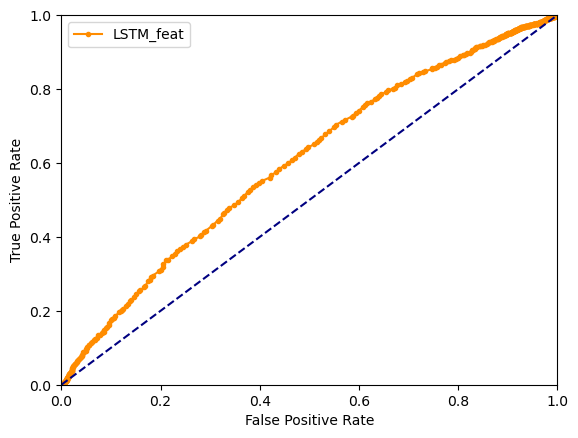

In [36]:
# roc curve
lstm_fpr, lstm_tpr, lstm_thresholds = metrics.roc_curve(y_true, pred_probs)

# plot the roc curve for the model
plt.figure()
plt.ylim(0.0, 1.0)
plt.xlim(0.0, 1.0)
plt.plot(lstm_fpr, lstm_tpr, marker=".", label="LSTM_feat", color="darkorange")
plt.plot([0, 1], [0, 1], color="navy", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

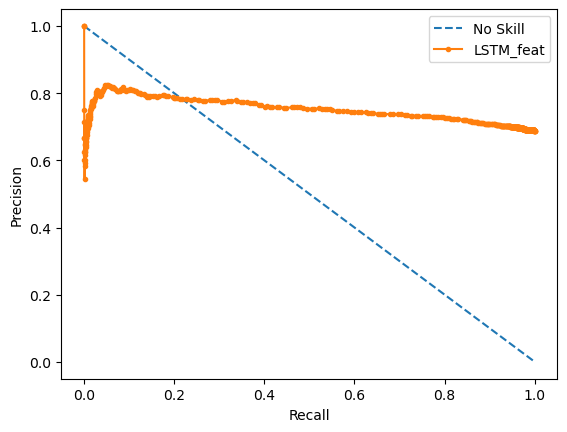

In [37]:
# pr curve
lstm_precision, lstm_recall, _ = metrics.precision_recall_curve(y_true, pred_probs)

# plot the precision-recall curves
plt.plot([0, 1], [1, 0], linestyle="--", label="No Skill")
plt.plot(lstm_recall, lstm_precision, marker=".", label="LSTM_feat")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

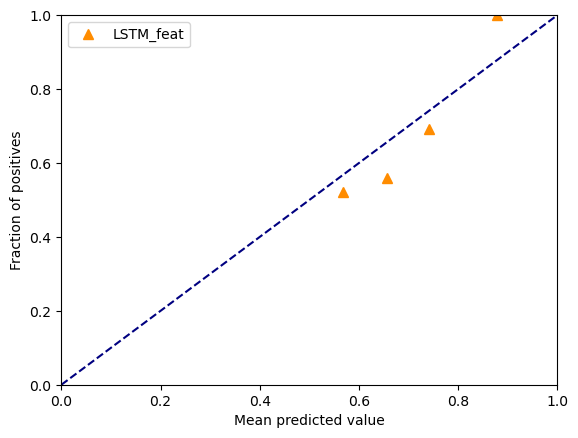

In [38]:
# calibration curve
lstm_y, lstm_x = calibration_curve(y_true, pred_probs, n_bins=10)
plt.figure()
plt.ylim(0.0, 1.0)
plt.xlim(0.0, 1.0)
plt.plot(lstm_x, lstm_y, marker="^", linestyle="", markersize=7, label="LSTM_feat", color="darkorange")

plt.plot([0, 1], [0, 1], color="navy", linestyle="--")

plt.xlabel("Mean predicted value")
plt.ylabel("Fraction of positives")
plt.legend()
plt.show()